To start this notebook, run the following code blocks to import all relevant modules and to define a function we will use a lot later.

In [1]:
# Relevant imports for the notebook
import os
from typing import Optional, Union
from tests.tests import EA_RL_Tests

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Video, clear_output
from matplotlib import animation
from stable_baselines3 import DDPG, DQN
from stable_baselines3.common.base_class import BaseAlgorithm
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.noise import NormalActionNoise

SEED = 42
test = EA_RL_Tests()

2025-12-17 15:30:13.078534: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def record_one_episode(model: BaseAlgorithm, env: gym.Env, video_path: str, fps: int = 30) -> None:
    """
    Records one episode of the given model in the given environment and saves it as a video.

    :param model: The trained RL model
    :param env: The environment to record the episode in
    :param video_path: The path to save the video
    :param fps: The frames per second of the video
    """
    obs, _ = env.reset()
    frames = []
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        if terminated or truncated:
            break

    fig = plt.figure(figsize=(6, 6))
    plt.axis("off")
    img = plt.imshow(frames[0])

    def animate(i):
        img.set_array(frames[i])
        return img,

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), blit=True)

    if not os.path.exists("videos"):
        os.makedirs("videos")

    anim.save(video_path, fps=fps)
    plt.close()

# 4.8 Continuous Environments and DDPG

In this notebook, we will work with a continuous environment (meaning the action / observation spaces are continuous) and later on optimize it with evolutionary algorithms. One such continuous environment is the [Inverted Pendulum environment](https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/#inverted-pendulum) (see video below).

The agent can observe the position of the cart and the pole and the velocities of the cart and the pole. The goal is to balance the pole like seen in the video below. Luckily for us, this environment is included in gymnasium and we can use it just like the frozenlake environemnt.

![Inverted Pendulum](images/inverted_pendulum.gif)

There is one problem though with continuous environments: We can not use Q Learning for these continuous environments, since Q Learning hinges on maintaining a table of Q‑values for **every possible** state–action pair and, at each step, picking the action that maximizes Q.

In a continuous action world, however, there are infinitely many possible actions at each state, so finding that maximizing action would itself require solving a complex optimization problem every time you act, and if you try to discretize the actions, the number of choices explodes (“the curse of dimensionality”) and becomes intractable to explore or learn over.

In short, classic Q‑learning just can’t efficiently represent or search through an uncountable action space.

## 4.8.1 Deep Deterministic Policy Gradient (DDPG)
DDPG is a reinforcement learning algorithm designed specifically for continuous action spaces and uses an actor-critic structure with two main components:

- **The Actor** is a neural network that learns a policy: it takes in the current state and outputs the best continuous action to take.

- **The Critic** is another neural network that learns the Q-function: it estimates how good a certain action is in a given state (i.e., the expected future reward).

Here's how DDPG works:

- The agent collects experiences (state, action, reward, next state) by interacting with the environment, and stores them in a replay buffer. This allows the algorithm to learn from past experiences and avoid instability caused by learning from highly correlated data.

- The Critic network is trained to minimize the difference between its predicted Q-values and the actual rewards plus future estimates (like in Q-learning), using target networks to provide stable learning targets.

- The Actor network is trained using feedback from the Critic. It adjusts its parameters to choose actions that the Critic believes lead to higher rewards. This is done using the deterministic policy gradient, which effectively nudges the Actor in a direction that improves expected performance.

- Target networks (slower-moving copies of the Actor and Critic) are used to make learning more stable by preventing sudden changes in the targets used for training.

In comparison to Q Learning, DDPG learns to produce the best action directly without searching all possible state-action pairs. The best part is: the python library stable_baselines3 makes it easy to just use DDPG. Let's try it out on the Inverted Pendulum environment!

<div class="alert alert-block alert-success">
<b>Task:</b> Train and save a DDPG model
<ul>
<li> Create a InvertedPendulum-v5 environment and set its render mode to "rgb_array"
<li> Instantiate a DDPG object with the given environment and the action noise</li>
<li> Train the model for 25.000 timeteps</li>
<li> Save the model under the given save path</li>
<li> Training can take a few minutes, we will explore how we can reduce training time significantly later</li>
</ul>

Hint: You can look up the basic usage here: https://stable-baselines3.readthedocs.io/en/master/modules/ddpg.html#example
</div>

In [5]:
ddpg_model_save_path = "models/ddpg_inverted_pendulum"

inverted_pendulum_env : gym.Env = None

# During learning, the actor will always choose the "best" action but we need it to explore other actions as well.
# So instead of always using the exact action the policy gives, we add some randomness (noise) to the action.
n_actions: int = None
action_noise : NormalActionNoise = None

ddpg_model: DDPG = None

# STUDENT CODE HERE (2 pts)
inverted_pendulum_env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")

n_actions = inverted_pendulum_env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

ddpg_model = DDPG(policy="MlpPolicy",env=inverted_pendulum_env,action_noise=action_noise, device="cuda")
ddpg_model.learn(total_timesteps=25000)

ddpg_model.save(ddpg_model_save_path)
# STUDENT CODE until HERE

del ddpg_model # delete the python object to demonstrate saving and loading

### 4.8.2 Visualizing your trained agent

The following code block loads your trained DDPG model and runs one episode with it. It saves each state of the environment as a frame in a video so that you can look how your trained agent is performing.

In [6]:
pendulum_video_save_path = "videos/inverted_pendulum.mp4"

ddpg_model = DDPG.load(ddpg_model_save_path)

record_one_episode(ddpg_model, inverted_pendulum_env, pendulum_video_save_path)

clear_output(wait=True)
Video(pendulum_video_save_path)

## 4.8.3 Let's have a look at another RL algorithm and another Environment

After exploring continuous control with DDPG on the InvertedPendulum, we now shift our focus to a classic discrete control problem: the **CartPole environment**.

While InvertedPendulum required continuous actions (forces applied to the base) and specialized algorithms like DDPG, CartPole has a simple discrete action space: the agent can either push the cart left or right.

This distinction matters because different types of environments and action spaces require different RL algorithms. DDPG and other actor–critic methods excel at continuous control, while value-based methods like **DQN (Deep Q-Network)** are well-suited for discrete action problems. A DQN is basically just the critic network of the DDPG, learning the Q-Function and trying to approximate the Q-values for each action.

Let's just get these code blocks running and see how good a standard DQN model with default hyperparameters performs on the CartPole environment.

<div class="alert alert-block alert-success">
<b>Task:</b> Train a DQN on the CartPole-v1 environment
<ul>
<li>Initialize the CartPole-v1 environment using "rgb_array" as its render_mode
<li>Create a DQN using this environment
<li>Let the DQN learn for 25.000 timesteps
<li>Save the DQN model under the given file path
</ul>
</div>

In [7]:
default_dqn_model_path = "models/default_dqn_model"

cartpole_env: gym.Env = None
default_dqn_model: DQN = None

# STUDENT CODE HERE (2 pts)
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")

default_dqn_model=DQN(policy="MlpPolicy",env=cartpole_env)

default_dqn_model.learn(total_timesteps=25000)

default_dqn_model.save(default_dqn_model_path)
# STUDENT CODE until HERE


mean_reward, _ = evaluate_policy(default_dqn_model, cartpole_env, n_eval_episodes=5)
print(f"Mean reward after training with random params: {mean_reward:.2f}")

Mean reward after training with random params: 9.40


/tools/lama/lama25-env/lib64/python3.12/site-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


### 4.8.4 How does our agent perform?

Let's visualize our DQN agent running one episode of the CartPole environment

In [ ]:
default_dqn_video_path = "videos/default_dqn.mp4"

default_dqn_model = DQN.load(default_dqn_model_path)

record_one_episode(default_dqn_model, cartpole_env, default_dqn_video_path)

clear_output(wait=True)
Video(default_dqn_video_path)

### 4.8.5 That does not look good, right?

The DQN seems to struggle with the task it's given and instantly fails the episode by tilting too much. There are two main options how we can solve this. We can:

- let the DQN train for longer and hope that it can solve the problem by then or
- optimize the hyperparameters of the DQN so that it can solve the problem faster/better.

In the next chapter, we will look into how we can automate the hyperparameter optimization process using Evolutionary Algorithms.

# 4.9 Genetic Algorithms optimizing Reinforcement Learning Hyperparameters

Genetic algorithms represent an approach to solve optimization problems. The concept is based on evolution theory like it is taught in a biology class. GAs can be categorized as generic optimization heuristics and are often used to find good solutions to [NP-complete problems](https://en.wikipedia.org/wiki/NP-completeness). GAs work especially well for problem that have a complex feature space and have multiple optimal solutions.

#### Terminology and Definitions

Before we go more into detail on the algorithm and its implementation, we have to introduce a common understanding and wording of the necessary steps and procedures. Following, the most important terms will be defined for this notebook:
 - **Population** or **Generation**: A group of individuals that is currently assessed.
 - **Individuum**: A single individual of a population. An individual contains genes that are parameters from an input feature space. Each individual has to be assessed using a fitness function.
 - **Fitness**: Similar to the cost function in other optimization algorithms. It represents the quality of each individual. Fitness refers to how fit (Deutsch: angepasst) an individual is to a certain problem/environment.

#### Procedure
A GA consists out of multiple steps. In the following we will implement each of them one after another and finally put all steps together to form a GA.

In this task we will focus on an objected oriented solution.

The following figure will give you a general overview about the individual steps of an GA ([source](https://pymoo.org/algorithms/soo/ga.html#nb-ga)):

<img src="images/ga_basic.png" alt="ea_flow" width= "500px"/>

### 4.9.0 Vectorized Environments

We will be doing a lot of training of DQN agents for the evaluation of the individuals fitness' and (for the sake of time and sanity) cannot depend on training on one single environment every time. To speed up training and evaluation, we will make use of **Vectorized Environments**.

**Vectorized Environments** are a method for using $n$ independent environments in parallel for training and letting the agent observe and react to these $n$ environments each step. The agent is essentially "playing" n different games in parallel.

If we now want to train a model for $t$ timesteps, we only need to wait $t/n$ timesteps instead (simplified), significantly reducing training time.

The interface for using Vectorized Environments is similar to the standard Gymnasium API, but it uses an array of observations, rewards, etc. instead of singular values. You can read more about Vectorized Environments here: https://stable-baselines3.readthedocs.io/en/master/guide/vec_envs.html

In [ ]:
cartpole_vec_env = make_vec_env("CartPole-v1", n_envs=8, seed=SEED)

## 4.9.1 The Individual and the fitness function

As stated before, we will use objected oriented programming mostly throughout this task. Hence, we will first implement an interface class called Individual from, which we can derive more specific child classes, e.g., for our DQN.

We will provide you with the first class `Individual`. It has two attributes: the parameters (e.g., considering our separation problem: a, b and c) and a fitness value. Please note, the fitness function has a property decorator, which essentially makes it read-only variable. When the fitness is accessed for the first time it automatically calls the `_evaluate_fitness` function. This function is given as prototype and has to be overloaded in specific child classes. The function `__init__` is the constructor for the class and takes a list of parameters.

In [ ]:
class Individual():
    _parameter: dict
    _fitness: float

    def __init__(self, parameter: dict) -> None:
        self._parameter = parameter

    def _evalute_fitness(self):
        pass

    @property
    def fitness(self) -> float:
        self._evalute_fitness()
        return self._fitness


In [ ]:
class IndividualForDQN(Individual):
    """
    Represents an individual in the population with DQN hyperparameters.
    
    Attributes:
        _parameter: Dictionary of DQN hyperparameters
        _fitness: Cached fitness score of this individual
    """
    _parameter: dict
    _fitness: float = None

    def __init__(self, parameter: dict) -> None:
        """
        Initialize with DQN hyperparameters.
        
        Args:
            parameter: Dictionary of hyperparameter names and values
        """
        self._parameter = parameter

    def _evalute_fitness(self):
        """
        Evaluates fitness by training a DQN with these hyperparameters.
        Updates the _fitness attribute with the mean reward achieved.
        """
        cartpole_vec_env.reset()
        model = DQN("MlpPolicy", cartpole_vec_env, seed=SEED, **self._parameter)
        model.learn(total_timesteps=25_000)
        mean_reward, _ = evaluate_policy(model, cartpole_vec_env, n_eval_episodes=10, warn=False)
        self._fitness = mean_reward

    @property
    def fitness(self) -> float:
        if self._fitness is None:
            self._evalute_fitness()
        return self._fitness

    def __str__(self) -> str:
        return f"Indiviuum with fitness={self._fitness} and params: {str(self._parameter)}"

## 4.9.2 Start of your GA - The initial population

Before we can go through all the steps of an GA, we have to generate a stating population with random individuals.

In [ ]:
def create_random_population(size: int) -> list[Individual]:
    """
    Creates a random initial population of DQN hyperparameter sets.
    
    Args:
        size: Number of individuals to create
        
    Returns:
        List of IndividualForDQN objects with randomized hyperparameters
    """
    pop = []
    for _ in range(size):
        ind = IndividualForDQN({
            "learning_rate": 10 ** np.random.uniform(-5, -3),
            "buffer_size": np.random.choice([10000, 20000, 50000]),
            "batch_size": np.random.choice([32, 64, 128]),
            "gamma": np.random.uniform(0.95, 0.999),
            "exploration_fraction": np.random.uniform(0.1, 0.5),
            "exploration_final_eps": np.random.uniform(0.01, 0.1)
        })
        pop.append(ind)
    return pop

## 4.9.3 Steps of the GA - We start with selection of the parents

Before we implement the first step of the GA, we stick to our object-oriented programming style and first define an abstract `GAStep` class. From this class we derive all steps. The `_do` function is called with an input population that gets modified and returned.

In [ ]:
class GAStep():
    def __init__(self) -> None:
        pass

    def _do(self, population: list[Individual], **kwargs) -> list:
        pass

The first step in a GA is to select some individuals, which will act as parents for the individuals of the next generation.
Usually some of the best individuals are mixed with random selected ones, in order to prevent optimization to rather a local than the global maximum.

<div class="alert alert-block alert-success">
<b>Task:</b> Implement the selection step.
<ul>
<li>Your selection step should return a list of individuals that contains a number of <i>_amount_best</i> of the best individuals and a number of <i>_amount_random</i> random individuals.</li>
<li> Hint: To access the attributes of your class, you always have to put <code>self</code> in front. E.g, <code>self._amount_best</code></li>
<li> To get the best individuals, use sort with the key option</li> 
</ul>
</div>

In [ ]:
class Selection(GAStep):
    """
    Selection step that chooses parent individuals for breeding.
    Combines best performing individuals with random ones for diversity.
    """
    def __init__(self, amount_best, amount_random) -> None:
        self._amount_best = amount_best
        self._amount_random = amount_random

    def _do(self, population: list[Individual]) -> list[Individual]:
        assert self._amount_best + self._amount_random <= len(population), "Selection size exceeds population size"

        selection: list = []
        
        ### STUDENT CODE HERE (2 pts)
        import random

        sorted_population = sorted(population,key=lambda ind: ind.fitness,reverse=True)

        best_individuals = sorted_population[:self._amount_best]
        remaining = sorted_population[self._amount_best:]

        random_individuals = random.sample(remaining, self._amount_random)

        selection = best_individuals + random_individuals
        ### STUDENT CODE until HERE

        return selection


# test
test_pop = create_random_population(10)
sel = Selection(amount_best=5, amount_random=5)
test.test_selection(sel, test_pop)

Your data looks alright, you can continue with the workbook


## 4.9.4 Breed some offspring

After the parents are selected the next step is to breed their children. In the beginning the parents are randomly grouped into tuples, let's call them mother and father. Each couple can give birth to a fixed amount of children. Each kid will inherit each of its parameters either from its mother or father, which is decided randomly. This parameter selection process is also called `crossover`.

**Hint:** It is often useful to keep the population size constant. In some cases it can even be helpful to reduce the population size.

<div class="alert alert-block alert-success">
<b>Task:</b> Implement the mutate step.
<ul>
<li>Your crossover step should randomly select pairs of parents from the input population and then generate a number of <i>children_per_couple</i> children</li>
<li>The function <code>_pairwise</code> is provided for you. It basically takes a list, e.g., [1,2,3,4] and returns pairs like: [[1,2], [3,4]]. Use it to generate the parent pairs</li>
</ul>
</div>

In [ ]:
class Crossover(GAStep):
    """
    Performs crossover between pairs of parent individuals to create offspring.
    
    This class implements genetic crossover by pairing parents and having each pair
    produce children that inherit parameters randomly from either parent.
    """
    def __init__(self, children_per_couple: int) -> None:
        """
        Initialize crossover parameters.
        
        Args:
            children_per_couple: Number of children to create from each parent pair
        """
        self._children_per_couple = children_per_couple

    def _pairwise(self, iterable: list) -> zip:
        """
        Groups the iterable into consecutive pairs.
        
        Args:
            iterable: List of items to pair up
            
        Returns:
            Iterator of pairs from the input list
        """
        return zip(*[iter(iterable)]*2)

    def _do(self, population: list[Individual]) -> list[Individual]:
        """
        Performs crossover to create new offspring from parent population.
        
        Takes the parent population, pairs them up, and creates children by randomly
        inheriting hyperparameters from each parent in the pair.
        
        Args:
            population: List of parent individuals to breed from
            
        Returns:
            List of children created through crossover
        """
        children: list = []

        ### STUDENT CODE HERE (3 pts)
        import random

        random.shuffle(population)

        for mother, father in self._pairwise(population):
            for _ in range(self._children_per_couple):

                child_params = {}
                for key in mother._parameter.keys():
                    child_params[key] = random.choice(
                        [mother._parameter[key], father._parameter[key]]
                    )

                child = IndividualForDQN(child_params)
                children.append(child)

        ### STUDENT CODE until HERE
        
        return children

# test
test_pop = create_random_population(20)

cross = Crossover(children_per_couple=5)
test.test_crossover(cross, test_pop)

Your data looks alright, you can continue with the workbook


## 4.9.5 Let's apply some mutation

Similar to nature, an essential step of GAs is the use of randomized mutations to each recently added individual. This prevents from getting stuck in a local optimum. The mutations can add an offset to parameters, completely change a parameter or even introduce a new individual.

In our case, we can not use basic shifting/scaling of values since the parameters we mutate are in completely different orders of magnitude and need to be in a given range for stable_baselines3 to accept them and therefore need different mutation strategies.

In practice, there are a lot of ways you could do the mutate step and many can lead to good results. This is just one way.

In [ ]:
class Mutate(GAStep):
    """
    Mutation step for genetic algorithm that applies random changes to hyperparameters.
    
    This class implements genetic mutation by randomly modifying hyperparameters
    of individuals based on a mutation probability. Different mutation strategies
    are used for different parameter types (log-float, float, int).
    """
    def __init__(self, mutation_propbability: float) -> None:
        """
        Initialize mutation parameters.
        
        Args:
            mutation_propbability: Probability (0-1) of mutating each hyperparameter
        """
        self._mutation_probability = mutation_propbability

    def _mutate_hyperparam(
        self,
        param: Union[float, int],
        std: float = 0.1,
        param_type: Optional[str] = None,
        clip_min: Optional[Union[float, int]] = None,
        clip_max: Optional[Union[float, int]] = None
    ) -> Union[float, int]:
        """
        Mutates a single hyperparameter value using Gaussian noise.
        
        Args:
            param: Original parameter value to mutate
            std: Standard deviation for Gaussian mutation
            param_type: Type of parameter ('log_float', 'float', or 'int')
            clip_min: Minimum allowed value after mutation
            clip_max: Maximum allowed value after mutation
            
        Returns:
            Mutated parameter value
            
        Raises:
            ValueError: If param_type is not one of the allowed values
        """
        if param_type == 'log_float':
            # Apply Gaussian mutation in log-space
            log_val = np.log10(param)
            mutated = log_val + np.random.normal(0, std)
            new_val = 10 ** mutated
            new_val = float(np.clip(new_val, clip_min, clip_max)) if clip_min and clip_max else float(new_val)

        elif param_type == 'float':
            mutated = param + np.random.normal(0, std * abs(param))
            new_val = float(np.clip(mutated, clip_min, clip_max)) if clip_min and clip_max else float(mutated)

        elif param_type == 'int':
            mutated = param + np.random.normal(0, std * max(param, 1))
            new_val = int(np.clip(round(mutated), clip_min, clip_max)) if clip_min and clip_max else int(round(mutated))

        else:
            raise ValueError("param_type must be 'float', 'log_float', or 'int'")
        
        return new_val

    def _do(self, population: list[Individual]) -> list[Individual]:
        """
        Applies mutations to a population of individuals.
        
        For each individual in the population, each hyperparameter has a chance to be
        mutated based on the mutation probability. Mutations are applied using
        different strategies depending on the hyperparameter type.
        
        Args:
            population: List of individuals to mutate
            
        Returns:
            List of mutated individuals
        """
        for i, individual in enumerate(population):
            parameter = individual._parameter.copy()

            for key, value in parameter.items():
                if np.random.random() < self._mutation_probability:
                    if key == "learning_rate":
                        parameter[key] = self._mutate_hyperparam(value, std=0.3, param_type='log_float', clip_min=1e-5, clip_max=1e-2)
                    elif key == "buffer_size":
                        parameter[key] = self._mutate_hyperparam(value, std=0.3, param_type='int', clip_min=10_000, clip_max=100_000)
                    elif key == "batch_size":
                        parameter[key] = self._mutate_hyperparam(value, std=0.3, param_type='int', clip_min=32, clip_max=512)
                    elif key == "gamma":    
                        parameter[key] = self._mutate_hyperparam(value, std=0.01, param_type='float', clip_min=0.9, clip_max=0.999)
                    elif key == "exploration_fraction":
                        parameter[key] = self._mutate_hyperparam(value, std=0.1, param_type='float', clip_min=0.05, clip_max=0.5)
                    elif key == "exploration_final_eps":
                        parameter[key] = self._mutate_hyperparam(value, std=0.2, param_type='log_float', clip_min=0.01, clip_max=0.1)
                    else:
                        raise ValueError(f"Unknown hyperparameter: {key}")
                
            population[i] = IndividualForDQN(parameter)

        return population

# test
test_pop = create_random_population(10)
print(test_pop[0]) # Original
mutate = Mutate(mutation_propbability=1.0)
print(mutate._do(test_pop)[0]) # Mutated

Indiviuum with fitness=None and params: {'learning_rate': 0.0007504995755775713, 'buffer_size': np.int64(10000), 'batch_size': np.int64(64), 'gamma': 0.987451426072511, 'exploration_fraction': 0.4647718565388175, 'exploration_final_eps': 0.06203378494812769}
Indiviuum with fitness=None and params: {'learning_rate': 0.0008286587429955567, 'buffer_size': 10000, 'batch_size': 57, 'gamma': 0.9886161971451486, 'exploration_fraction': 0.4455190237147053, 'exploration_final_eps': 0.04875887957705304}


## 4.9.6 Now we have to select the fittest individuals

<div class="alert alert-block alert-success">
<b>Task:</b> Implement the survival step.
<ul>
<li>This step should be reasonably simple. Just keep <i>n_individuals</i> individuals that have the highest fitness score.</li>
<li>Hint: Make sure the list you return is sorted by descending fitness, this will make your life easier later.</li>
</ul>
</div>

In [ ]:
class Survival(GAStep):
    """
    Survival step for genetic algorithm that selects the fittest individuals.
    
    This class implements the survival selection by keeping the n best individuals
    based on their fitness scores. This creates selection pressure towards better solutions.
    """
    def __init__(self, n_individuals: int) -> None:
        """
        Initialize survival parameters.
        
        Args:
            n_individuals: Number of individuals to keep in the population
        """
        self._n = n_individuals

    def _do(self, population: list[Individual]) -> list[Individual]:
        """
        Performs survival selection on the population.
        
        Sorts the population by fitness in descending order and keeps the top n individuals.
        
        Args:
            population: List of individuals to select from
            
        Returns:
            List of surviving individuals with highest fitness scores, length <= n_individuals
        """
        ### STUDENT CODE HERE (1 pt)
        sorted_population = sorted(population,key=lambda ind: ind.fitness,reverse=True)

        
        return sorted_population[:self._n]

        ### STUDENT CODE until HERE

test_pop = create_random_population(10)
test.test_survival(Survival(n_individuals=5), test_pop)

Your data looks alright, you can continue with the workbook


## 4.9.7 Put it all together!

<div class="alert alert-block alert-success">
<b>Task:</b> Implement the evolve function of our new GeneticAlgorithm class.
<ul>
<li>The function should perform the steps over a given number of generations</li>
<li>First select parents, then breed children and mutate them. Afterward perform an assessment using the survival step of the new children and the old population to get the new population</li>
</ul>
</div>

In [ ]:
class GeneticAlgorithm:
    """
    Genetic Algorithm implementation for optimizing DQN hyperparameters.
    
    This class implements a genetic algorithm that evolves a population of DQN 
    hyperparameter sets through selection, crossover, mutation and survival steps
    to find optimal configurations.
    
    Attributes:
        _population: Current population of individuals
        _selection_step: Strategy for selecting parent individuals
        _crossover_step: Strategy for breeding new individuals
        _mutate_step: Strategy for mutating individuals
        _survival_step: Strategy for selecting survivors
        history: List tracking population history across generations
    """
    _population: list[Individual]
    _selection_step: GAStep
    _crossover_step: GAStep
    _mutate_step: GAStep
    _survival_step: GAStep
    history: list

    def __init__(self, 
                 starting_population: list[Individual],
                 selection_step: GAStep,
                 crossover_step: GAStep, 
                 mutate_step: GAStep,
                 survivial_step: GAStep) -> None:
        """
        Initialize genetic algorithm with population and evolution strategies.
        
        Args:
            starting_population: Initial population of individuals
            selection_step: Strategy for selecting parents
            crossover_step: Strategy for breeding offspring
            mutate_step: Strategy for mutating individuals
            survivial_step: Strategy for selecting survivors
        """
        self._population = starting_population
        self._selection_step = selection_step
        self._crossover_step = crossover_step
        self._mutate_step = mutate_step
        self._survival_step = survivial_step

        self.history = []
        self.history.append(self._population)

    def evolve(self, generations: int) -> None:
        """
        Evolve the population for a specified number of generations.
        
        For each generation:
        1. Select parents from current population
        2. Create offspring through crossover
        3. Apply mutations to offspring
        4. Select survivors from combined offspring and original population
        5. Track population history
        
        Args:
            generations: Number of generations to evolve
        """

        for i in range(generations):

            ### STUDENT CODE HERE (3 pts)
            parents = self._selection_step._do(self._population)
            children = self._crossover_step._do(parents)
            mutated_children = self._mutate_step._do(children)

            combined_population = self._population + mutated_children
            self._population = self._survival_step._do(combined_population)

            ### STUDENT CODE until HERE

            # print some information
            print(f"Generation {i+1}/{generations} finished:")
            print(f"    Best individual: {max(self._population, key=lambda ind: ind.fitness)}")

            self.history.append(self._population)


### 4.9.8 Let's test it out!

The following piece of code creates a sample population with 25 individuals and evolves it over 15 generation. Ideally your fitness score should rise in the process. This can take a few minutes.

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "8"


np.random.seed(SEED)
torch.manual_seed(SEED)
cartpole_vec_env.seed(SEED)
cartpole_vec_env.reset()

# run example
start_pop = create_random_population(25)

# steps
selection_step = Selection(amount_best=10, amount_random=10)
crossover_step = Crossover(children_per_couple=2)
mutate_step = Mutate(mutation_propbability=0.3)
survival_step = Survival(n_individuals=25)

algo = GeneticAlgorithm(start_pop, selection_step, crossover_step, mutate_step, survival_step)

out = algo.evolve(15)

Generation 1/15 finished:
    Best individual: Indiviuum with fitness=58.9 and params: {'learning_rate': 0.0005841986080198001, 'buffer_size': np.int64(20000), 'batch_size': np.int64(128), 'gamma': 0.9939084736962511, 'exploration_fraction': 0.22720138998874556, 'exploration_final_eps': 0.01990467320749091}
Generation 2/15 finished:
    Best individual: Indiviuum with fitness=58.9 and params: {'learning_rate': 0.0005841986080198001, 'buffer_size': np.int64(20000), 'batch_size': np.int64(128), 'gamma': 0.9939084736962511, 'exploration_fraction': 0.22720138998874556, 'exploration_final_eps': 0.01990467320749091}
Generation 3/15 finished:
    Best individual: Indiviuum with fitness=59.7 and params: {'learning_rate': 0.0007554641432039245, 'buffer_size': 55902, 'batch_size': np.int64(64), 'gamma': 0.969901495020029, 'exploration_fraction': 0.5, 'exploration_final_eps': 0.08650347200108194}
Generation 4/15 finished:
    Best individual: Indiviuum with fitness=59.7 and params: {'learning_rat

### 4.9.9 See the Optimization Progress

<div class="alert alert-block alert-success">
<b>Task:</b> Visualize the training process.
<ul>
<li> Plot the best fitness and average fitness for each generation</li>
<li> Make sure the plot has all relevant information like title and axis labels</li>
</ul>
</div>

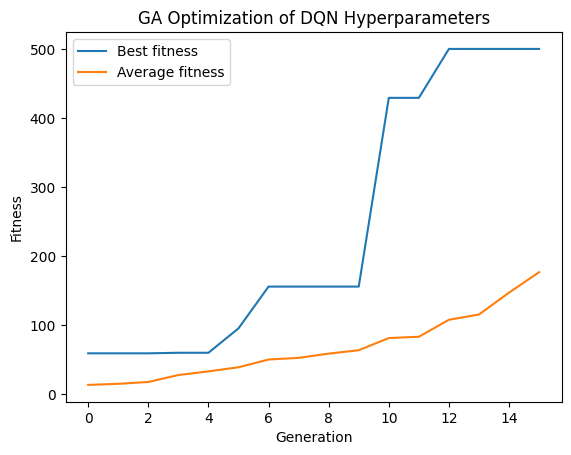

In [ ]:
# STUDENT CODE HERE (3 pts)

best = [max(ind.fitness for ind in pop) for pop in algo.history]
avg = [np.mean([ind.fitness for ind in pop]) for pop in algo.history]

plt.figure()
plt.plot(best, label="Best fitness")
plt.plot(avg, label="Average fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("GA Optimization of DQN Hyperparameters")
plt.legend()
plt.show()



# STUDENT CODE until HERE

## 4.9.10 Use the found parameters to train a DQN

Now that we have found some good set of parameters for the DQN, let's try training a DQN with them and see how good it performs compared to the default hyperparameter values.

<div class="alert alert-block alert-success">
<b>Task:</b> Train a DQN with the parameters that had the best fitness
<ul>
<li>Extract the parameters that gained the best fitness score from the <code>algo.history</code> attribute</li>
<li>Create a DQN using these parameters and the CartPole vectorized environment, don't forget to set the seed</li>
<li>Train the DQN for 25.000 timesteps and save it under the given path</li>
</ul>
</div>

In [ ]:
optimized_dqn_model_path = "models/optimized_dqn_model"
cartpole_vec_env.reset()

optimized_dqn_model = None

# STUDENT CODE HERE (2 pts)
best_individual = max((ind for population in algo.history for ind in population),key=lambda ind: ind.fitness)
best_params = best_individual._parameter

optimized_dqn_model=DQN(policy="MlpPolicy",env=cartpole_vec_env,seed=SEED,**best_params,device="cuda")

optimized_dqn_model.learn(total_timesteps=25000)

optimized_dqn_model.save(optimized_dqn_model_path)
# STUDENT CODE until HERE

cartpole_vec_env.reset()
mean_reward, _ = evaluate_policy(optimized_dqn_model, cartpole_vec_env, n_eval_episodes=10)
print(f"Mean reward after training with optimized params: {mean_reward:.2f}")

Mean reward after training with optimized params: 461.80


### 4.9.11 Let's have a look at how it performs

In [ ]:
optimized_dqn_video_path = "videos/optimized_dqn.mp4"

cartpole_single_env = gym.make("CartPole-v1", render_mode="rgb_array")
optimized_dqn_model = DQN.load(optimized_dqn_model_path)

record_one_episode(optimized_dqn_model, cartpole_single_env, optimized_dqn_video_path)

clear_output(wait=True)
Video(optimized_dqn_video_path)

## 4.9.12 Comparison to the default values

In this last part, we again have a look at how the default values of the DQN perform with the same number of timesteps and on the same environment. Are your found parameters better than the default ones?

In [ ]:
default_dqn_model_path = "models/default_dqn_model"
cartpole_vec_env.reset()

default_dqn_model = DQN(
    "MlpPolicy",
    cartpole_vec_env,
    seed=SEED,
)

default_dqn_model.learn(25_000)
default_dqn_model.save(default_dqn_model_path)

cartpole_vec_env.reset()
mean_reward, _ = evaluate_policy(default_dqn_model, cartpole_vec_env, n_eval_episodes=10)
print(f"Mean reward after training with default params: {mean_reward:.2f}")

del default_dqn_model

Mean reward after training with default params: 9.50


In [ ]:
default_dqn_video_path = "videos/default_dqn.mp4"

default_dqn_model = DQN.load(default_dqn_model_path)

record_one_episode(default_dqn_model, cartpole_single_env, default_dqn_video_path)

clear_output(wait=True)
Video(default_dqn_video_path)

# Feedback and Recap

<div class="alert alert-block alert-success">
<b>Question (4 pts): Answer these questions in a few sentences.</b>
<ul>
<li> 1. What is the basic idea of reinforcement learning?
<li> 2. How does Q Learning work and why is it an "off-policy training" algorithm?
<li> 3. What are the challenges of continuous environments for Q Learning?
<li> 4. Think of a real life application where reinforcement learning could be a better approach than other machine learning techniques.
</ul>
</div>
<div class="alert alert-block alert-success">
<b>Your Answer:</b> 
1. Die Grundidee des Reinforcement Learning ist, dass ein Agent durch Interaktion mit einer Umgebung lernt, welches Verhalten am besten ist. Er erhält Belohnungen oder Strafen als Feedback und passt seine Strategie so an, dass die langfristige Belohnung maximiert wird.<br>
2. Q-Learning lernt eine Q-Funktion, die bewertet, wie gut eine bestimmte Aktion in einem bestimmten Zustand ist. Die Q-Werte werden mithilfe der Bellman-Gleichung aktualisiert. Es ist ein Off-Policy-Algorithmus, da die optimale Strategie gelernt wird, unabhängig von der aktuell verwendeten Explorationsstrategie.<br>
3. In kontinuierlichen Umgebungen gibt es unendlich viele Zustände, sodass benutzten einer Q-Tabelle sinnfrei ist, aufgrund von riesigen Speicher/Rechenaufwand bedarf.<br>
4. Autonomes Fahren wäre ein Beispiel, da es nicht für jede Verkehrssituation passende Labels gibt und ein System diese Situationen selbstständig anhand von Feedback erlernen muss. 
</div>